In [6]:
import pandas as pd

# Load orders dataset
orders = pd.read_csv("/content/olist_orders_dataset.csv")

# Convert timestamp to datetime
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp'], errors='coerce'
)

# Drop rows with missing timestamps
orders = orders.dropna(subset=['order_purchase_timestamp'])

# Create daily aggregation (number of orders per day)
sales_ts = (
    orders
    .set_index('order_purchase_timestamp')
    .resample('D')
    .size()
    .reset_index(name='sales')
)

# Save as CSV
sales_ts.to_csv("ecommerce_sales_ts.csv", index=False)

print("ecommerce_sales_ts.csv created successfully!")
print(sales_ts.shape)
print(sales_ts.head(10))


ecommerce_sales_ts.csv created successfully!
(774, 2)
  order_purchase_timestamp  sales
0               2016-09-04      1
1               2016-09-05      1
2               2016-09-06      0
3               2016-09-07      0
4               2016-09-08      0
5               2016-09-09      0
6               2016-09-10      0
7               2016-09-11      0
8               2016-09-12      0
9               2016-09-13      1


In [22]:
import pandas as pd

# Load sensor dataset
sensor_df = pd.read_csv("/content/sensor.csv")

# Convert timestamp column
sensor_df['timestamp'] = pd.to_datetime(sensor_df['timestamp'], errors='coerce')

# Sort by time (VERY IMPORTANT for time series)
sensor_df = sensor_df.sort_values('timestamp')

# Drop duplicate timestamps if any
sensor_df = sensor_df.drop_duplicates(subset=['timestamp'])

# Optional: Reset index
sensor_df = sensor_df.reset_index(drop=True)

# Save clean base version
sensor_df.to_csv("sensor_data.csv", index=False)

print("sensor_data.csv created successfully!")
print(sensor_df.shape)
print(sensor_df.head())

sensor_data.csv created successfully!
(220320, 55)
   Unnamed: 0           timestamp  sensor_00  sensor_01  sensor_02  sensor_03  \
0           0 2018-04-01 00:00:00   2.465394   47.09201    53.2118  46.310760   
1           1 2018-04-01 00:01:00   2.465394   47.09201    53.2118  46.310760   
2           2 2018-04-01 00:02:00   2.444734   47.35243    53.2118  46.397570   
3           3 2018-04-01 00:03:00   2.460474   47.09201    53.1684  46.397568   
4           4 2018-04-01 00:04:00   2.445718   47.13541    53.2118  46.397568   

   sensor_04  sensor_05  sensor_06  sensor_07  ...  sensor_43  sensor_44  \
0   634.3750   76.45975   13.41146   16.13136  ...   41.92708  39.641200   
1   634.3750   76.45975   13.41146   16.13136  ...   41.92708  39.641200   
2   638.8889   73.54598   13.32465   16.03733  ...   41.66666  39.351852   
3   628.1250   76.98898   13.31742   16.24711  ...   40.88541  39.062500   
4   636.4583   76.58897   13.35359   16.21094  ...   41.40625  38.773150   

   se

EASY — Sub-step 1

In [8]:
import pandas as pd

df = pd.read_csv("ecommerce_sales_ts.csv")
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

df = df.sort_values('order_purchase_timestamp')
df.set_index('order_purchase_timestamp', inplace=True)

df.head()

,sales
order_purchase_timestamp,
2016-09-04,1
2016-09-05,1
2016-09-06,0
2016-09-07,0
2016-09-08,0


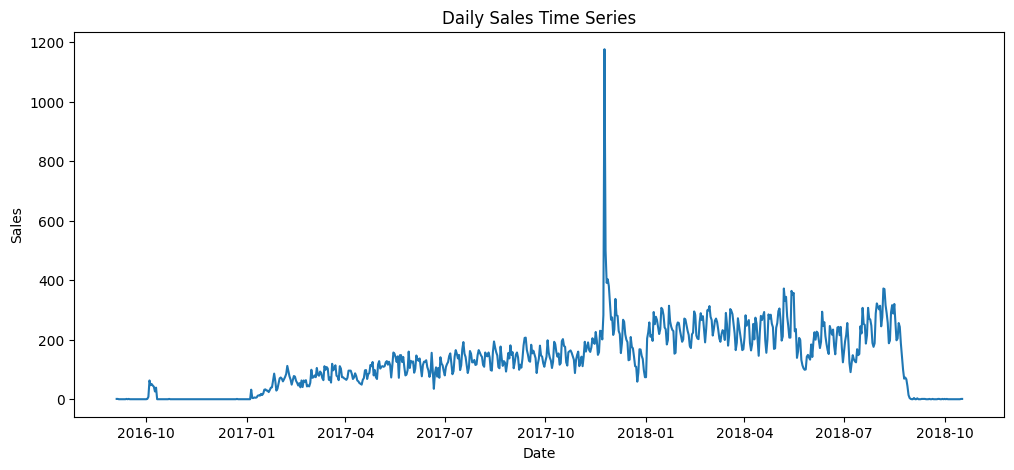

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df['sales'])
plt.title("Daily Sales Time Series")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

In [10]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['sales'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -2.3217349227820803
p-value: 0.16505381122077295


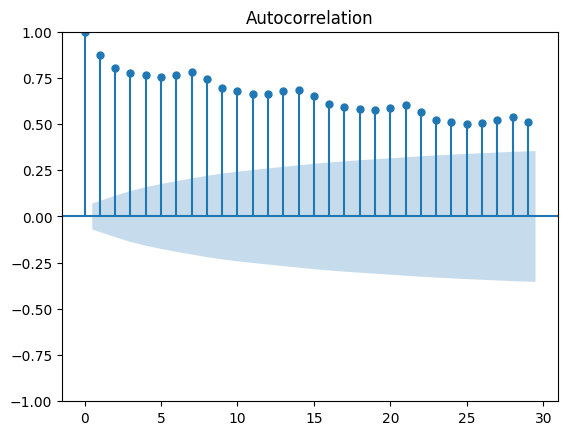

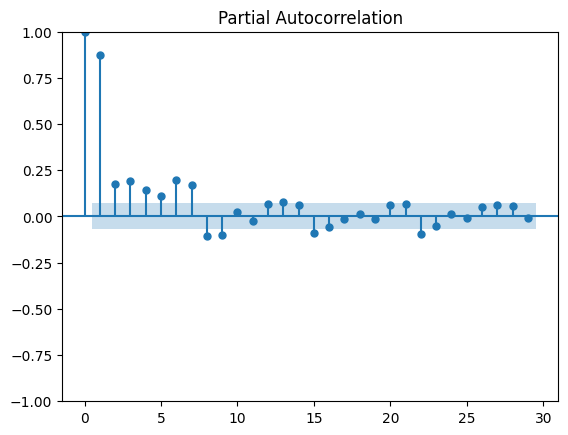

In [11]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df['sales'])
plot_pacf(df['sales'])
plt.show()

In [12]:
# Missing values
print(df.isnull().sum())

# Duplicates
print(df.index.duplicated().sum())

# Basic stats
print(df.describe())

sales    0
dtype: int64
0
             sales
count   774.000000
mean    128.476744
std     104.498687
min       0.000000
25%      42.250000
50%     124.000000
75%     198.000000
max    1176.000000


EASY — Sub-step 2

In [13]:
sensor = pd.read_csv("sensor_data.csv")

sensor['timestamp'] = pd.to_datetime(sensor['timestamp'])
sensor = sensor.sort_values('timestamp')

sensor.head()

,Unnamed: 0,timestamp,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,...,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51,machine_status
0,0,2018-04-01 00:00:00,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,...,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
1,1,2018-04-01 00:01:00,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,...,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
2,2,2018-04-01 00:02:00,2.444734,47.35243,53.2118,46.397570,638.8889,73.54598,13.32465,16.03733,...,41.66666,39.351852,65.39352,51.21528,38.194443,155.9606,67.12963,241.3194,203.7037,NORMAL
3,3,2018-04-01 00:03:00,2.460474,47.09201,53.1684,46.397568,628.1250,76.98898,13.31742,16.24711,...,40.88541,39.062500,64.81481,51.21528,38.194440,155.9606,66.84028,240.4514,203.1250,NORMAL
4,4,2018-04-01 00:04:00,2.445718,47.13541,53.2118,46.397568,636.4583,76.58897,13.35359,16.21094,...,41.40625,38.773150,65.10416,51.79398,38.773150,158.2755,66.55093,242.1875,201.3889,NORMAL


In [14]:
# Missing values
print(sensor.isnull().sum())

# Duplicate timestamps
print(sensor['timestamp'].duplicated().sum())

# Check time gaps
print(sensor['timestamp'].diff().value_counts().head())

Unnamed: 0             0
timestamp              0
sensor_00          10208
sensor_01            369
sensor_02             19
sensor_03             19
sensor_04             19
sensor_05             19
sensor_06           4798
sensor_07           5451
sensor_08           5107
sensor_09           4595
sensor_10             19
sensor_11             19
sensor_12             19
sensor_13             19
sensor_14             21
sensor_15         220320
sensor_16             31
sensor_17             46
sensor_18             46
sensor_19             16
sensor_20             16
sensor_21             16
sensor_22             41
sensor_23             16
sensor_24             16
sensor_25             36
sensor_26             20
sensor_27             16
sensor_28             16
sensor_29             72
sensor_30            261
sensor_31             16
sensor_32             68
sensor_33             16
sensor_34             16
sensor_35             16
sensor_36             16
sensor_37             16


In [19]:
# Check if 'timestamp' is a column before setting it as index
if 'timestamp' in sensor.columns:
    sensor.set_index('timestamp', inplace=True)

# Handle missing values
sensor = sensor.fillna(method='ffill')  # forward fill

# Optional: resample to fixed interval (example: hourly)
sensor = sensor.resample('H').mean(numeric_only=True)
sensor = sensor.fillna(method='ffill')

sensor.head()

/tmp/ipykernel_2815/1433698865.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  sensor = sensor.fillna(method='ffill')  # forward fill
/tmp/ipykernel_2815/1433698865.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  sensor = sensor.resample('H').mean(numeric_only=True)
/tmp/ipykernel_2815/1433698865.py:10: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  sensor = sensor.fillna(method='ffill')


,Unnamed: 0,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,sensor_08,...,sensor_42,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51
timestamp,,,,,,,,,,,,,,,,,,,,,
2018-04-01 00:00:00,29.5,2.454506,48.556132,53.142359,46.225404,634.120408,75.736439,13.363834,16.162107,15.702523,...,32.109373,40.338538,38.773147,50.053048,47.125772,39.313271,197.458523,78.168406,240.152398,210.030863
2018-04-01 01:00:00,89.5,2.454244,48.015769,53.106913,45.935328,634.236105,74.565887,13.593025,16.156681,15.712770,...,32.886282,39.878469,43.219522,47.333141,43.875385,39.303626,180.685768,73.384452,230.328902,203.737453
2018-04-01 02:00:00,149.5,2.453621,48.993053,53.010704,45.593169,634.427072,75.016876,13.596642,16.160780,15.667800,...,32.274303,39.939233,42.230902,50.901814,48.447145,38.478973,173.615937,75.848765,225.303813,209.997103
2018-04-01 03:00:00,209.5,2.454572,48.654513,52.975985,45.218459,633.416988,73.256377,13.604358,16.159333,15.688658,...,31.315104,39.626732,50.815008,53.747106,45.558450,38.334297,204.388503,104.639274,257.315780,222.680358
2018-04-01 04:00:00,269.5,2.453785,48.326822,52.868200,45.130930,634.986487,70.149835,13.585189,16.151497,15.702161,...,30.976561,39.578990,56.645447,69.227430,59.239969,38.532021,213.083523,114.178239,249.136765,211.641588


In [20]:
sensor.to_csv("sensor_data_cleaned.csv")

MEDIUM SUB-STEP 3 (SALES FORECASTING)

In [23]:
train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]
test = df.iloc[train_size:]

In [24]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train['sales'], order=(1,1,1))  # baseline choice
model_fit = model.fit()

print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                  619
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -3277.283
Date:                Tue, 14 Apr 2026   AIC                           6560.566
Time:                        15:12:37   BIC                           6573.846
Sample:                    09-04-2016   HQIC                          6565.729
                         - 05-15-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3980      0.034     11.555      0.000       0.330       0.466
ma.L1         -0.8869      0.028    -31.396      0.000      -0.942      -0.832
sigma2      2361.0574     17.140    137.751      0.0

In [25]:
predictions = model_fit.forecast(steps=len(test))

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test['sales'], predictions)
rmse = np.sqrt(mean_squared_error(test['sales'], predictions))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 151.53066613172354
RMSE: 182.86420941286724


MEDIUM SUB-STEP 4 (IMPROVED MODEL)



In [27]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_sarima = SARIMAX(
    train['sales'],
    order=(1,1,1),
    seasonal_order=(1,1,1,7)  # weekly seasonality
)

model_sarima_fit = model_sarima.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [29]:
pred_sarima = model_sarima_fit.forecast(steps=len(test))

In [30]:
mae_sarima = mean_absolute_error(test['sales'], pred_sarima)

print("ARIMA MAE:", mae)
print("SARIMA MAE:", mae_sarima)

ARIMA MAE: 151.53066613172354
SARIMA MAE: 172.7342405146688


MEDIUM SUB-STEP 5  (SENSOR FAILURE PREDICTION)

In [39]:
sensor = pd.read_csv("sensor_data.csv")
sensor['timestamp'] = pd.to_datetime(sensor['timestamp'])

# Drop columns that are entirely NaN (e.g., sensor_15)
sensor = sensor.dropna(axis=1, how='all')

# Handle NaNs before calculating rolling features using ffill
sensor = sensor.fillna(method='ffill')

# Example features
sensor['rolling_mean'] = sensor['sensor_01'].rolling(5).mean()
sensor['rolling_std'] = sensor['sensor_01'].rolling(5).std()

# Drop NaNs introduced by rolling calculations (first few rows)
sensor = sensor.dropna(subset=['rolling_mean', 'rolling_std'])

/tmp/ipykernel_2815/3858292148.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  sensor = sensor.fillna(method='ffill')


In [43]:
sensor['failure_next_24h'] = sensor['machine_status'].shift(-24)

sensor['failure_next_24h'] = sensor['failure_next_24h'].apply(lambda x: 1 if x != 'NORMAL' else 0)


In [41]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = sensor[['rolling_mean', 'rolling_std']]
y = sensor['failure_next_24h']

# Time-based split
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [42]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     44040
           1       0.00      0.00      0.00        24

    accuracy                           1.00     44064
   macro avg       0.50      0.50      0.50     44064
weighted avg       1.00      1.00      1.00     44064



HARD SUB-STEP 6 (Rule vs ML Model)

In [45]:
THRESHOLD = sensor['sensor_01'].mean() + 2 * sensor['sensor_01'].std()

sensor['rule_pred'] = (sensor['sensor_01'] > THRESHOLD).astype(int)

In [46]:
sensor['model_pred'] = model.predict(X)

In [47]:
# Example costs
COST_FN = 1000   # missing a failure (very costly)
COST_FP = 100    # false alarm (less costly)

In [48]:
def compute_cost(y_true, y_pred):
    cost = 0
    for yt, yp in zip(y_true, y_pred):
        if yt == 1 and yp == 0:
            cost += COST_FN
        elif yt == 0 and yp == 1:
            cost += COST_FP
    return cost

In [49]:
y_true = y

rule_cost = compute_cost(y_true, sensor['rule_pred'])
model_cost = compute_cost(y_true, sensor['model_pred'])

print("Rule Cost:", rule_cost)
print("Model Cost:", model_cost)

Rule Cost: 14742400
Model Cost: 2063600


HARD SUB-STEP 7 (Cost Optimization at Scale)

In [50]:
NUM_SENSORS = 100000

# Normalize cost per sample
cost_per_sample = model_cost / len(y_true)

daily_cost = cost_per_sample * NUM_SENSORS

print("Estimated Daily Cost:", daily_cost)

Estimated Daily Cost: 936654.623359175


In [51]:
import numpy as np

probs = model.predict_proba(X)[:,1]

thresholds = np.linspace(0, 1, 50)

best_cost = float('inf')
best_threshold = 0

for t in thresholds:
    preds = (probs > t).astype(int)
    cost = compute_cost(y_true, preds)

    if cost < best_cost:
        best_cost = cost
        best_threshold = t

print("Best Threshold:", best_threshold)
print("Minimum Cost:", best_cost)

Best Threshold: 0.1020408163265306
Minimum Cost: 1566800


In [52]:
from sklearn.metrics import f1_score

best_f1 = 0
best_f1_threshold = 0

for t in thresholds:
    preds = (probs > t).astype(int)
    f1 = f1_score(y_true, preds)

    if f1 > best_f1:
        best_f1 = f1
        best_f1_threshold = t

print("Best F1 Threshold:", best_f1_threshold)

Best F1 Threshold: 0.4693877551020408
